**Homework 3**

В этом ноутбуке создаю KNN модель(с помощью skikit-learn), которая будет классифицировать тип вина по 13 признакам. Датасет взял здесь https://gist.github.com/tijptjik/9408623 (это дубль UCI wine датасета, но с подписанными колонками в csv формате), он состоит из 177 записей и 14 признаков. 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
from sklearn.model_selection import train_test_split, cross_val_score
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.metrics import accuracy_score, confusion_matrix,
from scipy.spatial.distance import cosine


In [42]:

df = pd.read_csv("wine.csv")
df.head()

,Class,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intencity,Hue,0D280_0D315_of_diluted_wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


**2) EDA**

Здесь проверяю пропуски, размерность, типы признаков, потенциальные проблемы в данных. О результатх EDA подробнее- в конце блока

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Class                         178 non-null    int64  
 1   Alcohol                       178 non-null    float64
 2   Malicacid                     178 non-null    float64
 3   Ash                           178 non-null    float64
 4   Alcalinity_of_ash             178 non-null    float64
 5   Magnesium                     178 non-null    int64  
 6   Phenols                       178 non-null    float64
 7   Flavanoids                    178 non-null    float64
 8   Nonflavanoid_phenols          178 non-null    float64
 9   Proanthocyanins               178 non-null    float64
 10  Color_intencity               178 non-null    float64
 11  Hue                           178 non-null    float64
 12  0D280_0D315_of_diluted_wines  178 non-null    float64
 13  Proline         

In [44]:
df.shape

(178, 14)

In [45]:
df.describe()

,Class,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intencity,Hue,0D280_0D315_of_diluted_wines,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [46]:
df.isnull().sum()

Class                           0
Alcohol                         0
Malicacid                       0
Ash                             0
Alcalinity_of_ash               0
Magnesium                       0
Phenols                         0
Flavanoids                      0
Nonflavanoid_phenols            0
Proanthocyanins                 0
Color_intencity                 0
Hue                             0
0D280_0D315_of_diluted_wines    0
Proline                         0
dtype: int64

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, 'Alcohol'),
  Text(1, 0, 'Malicacid'),
  Text(2, 0, 'Ash'),
  Text(3, 0, 'Alcalinity_of_ash'),
  Text(4, 0, 'Magnesium'),
  Text(5, 0, 'Phenols'),
  Text(6, 0, 'Flavanoids'),
  Text(7, 0, 'Nonflavanoid_phenols'),
  Text(8, 0, 'Proanthocyanins'),
  Text(9, 0, 'Color_intencity'),
  Text(10, 0, 'Hue'),
  Text(11, 0, '0D280_0D315_of_diluted_wines'),
  Text(12, 0, 'Proline')])

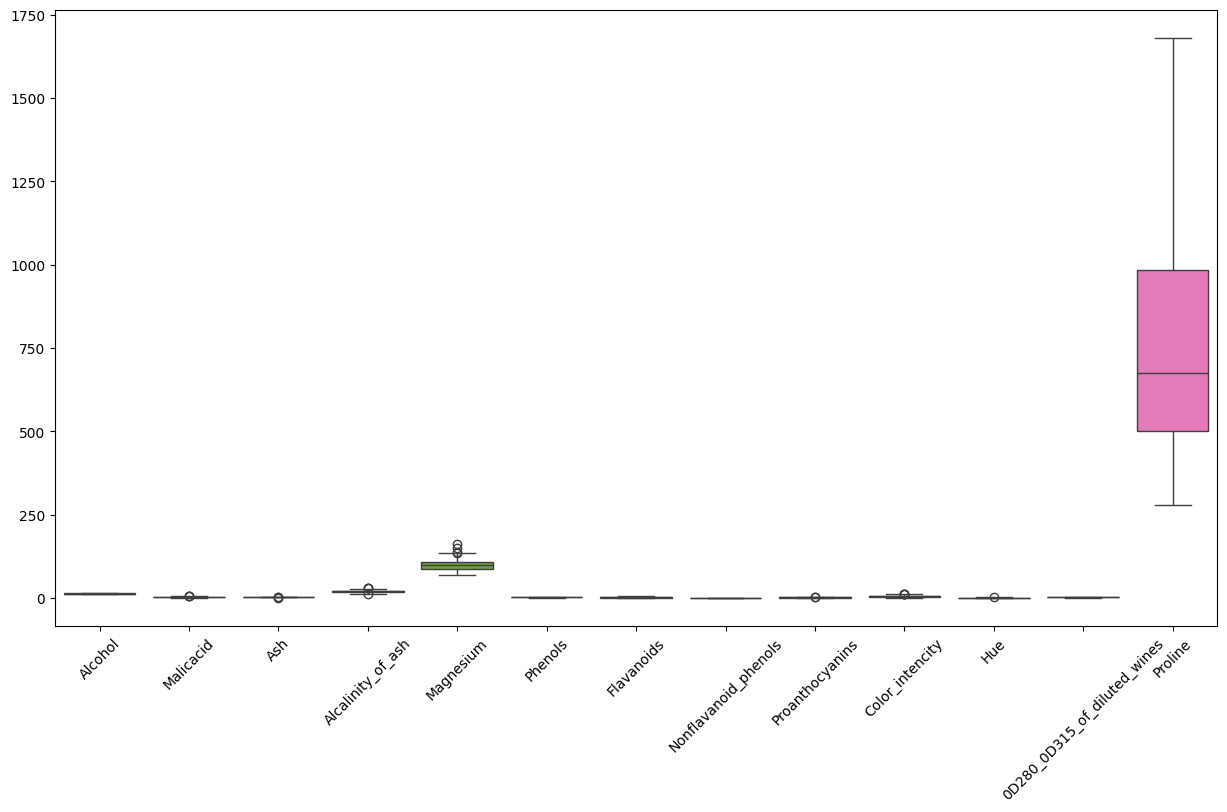

In [47]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df.drop('Class', axis=1))
plt.xticks(rotation=45)

<Axes: xlabel='Class', ylabel='count'>

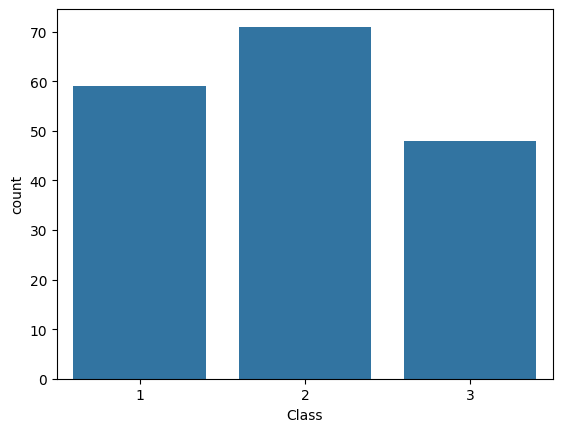

In [48]:
sns.countplot(x='Class', data=df)


<Axes: >

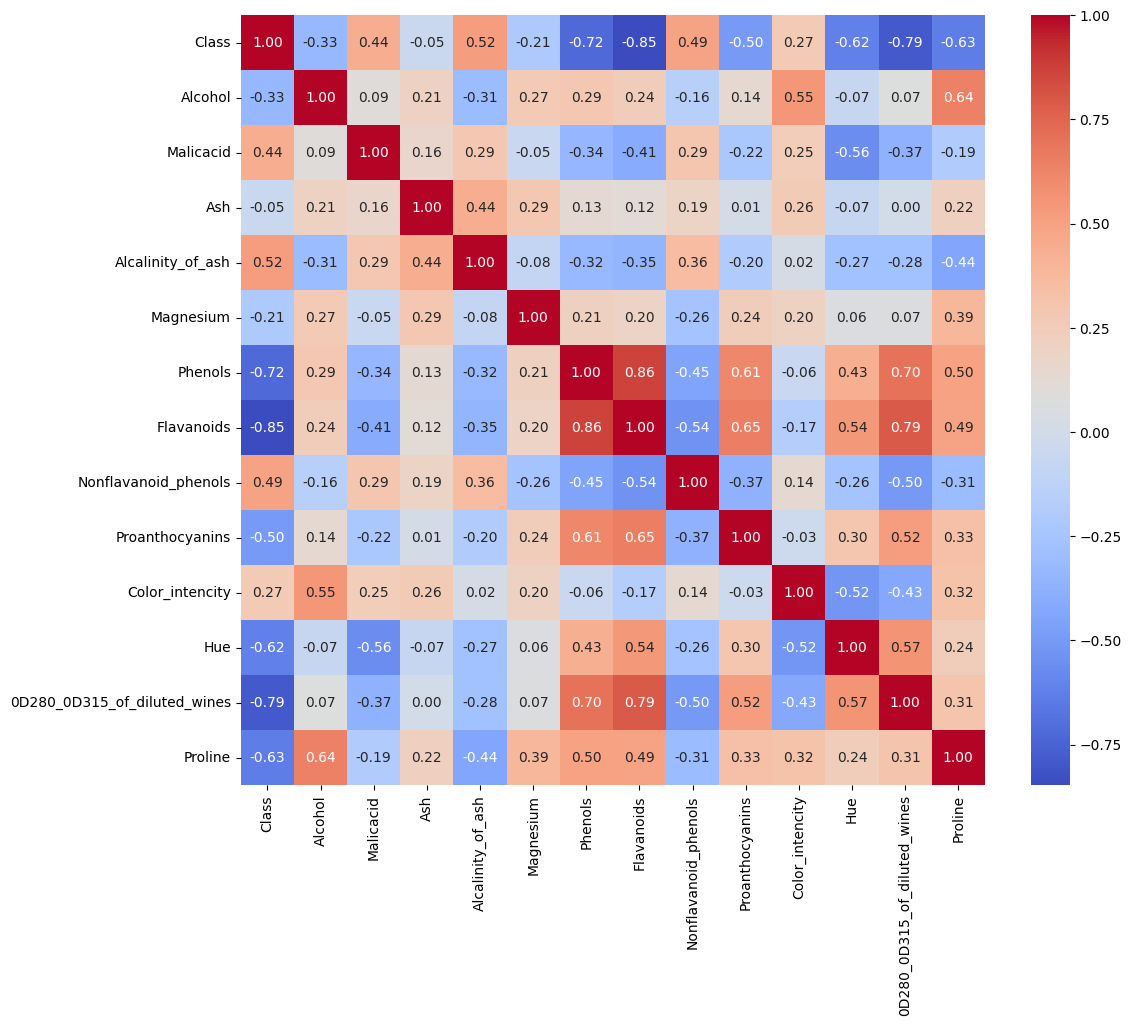

In [49]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')


Что узнал после EDA:

- размерность 178 x 14
- пропусков в данных нет
- все признаки нумерические 
- количество target классов распределено равномерно
- признаки Flavanoids и Phenols сильно коррелируют (0,86)
- при этом flavanoids сильно влияют на class, то есть таргетное значение (-0,85)
- значения признака Proline намного больше(в 10-100 раз по медиане) в масштабах, чем значения остальных признаков
- Признак Ash коррелирует с таргетов всего на -0.05 - почти что не влияет на результат

**3) Подготовка данных**

В этом блоке обрабатываю данные перед уже самим обучением kNN модели

По пунктам:
- Пропусков в данных нет, всё заполнено, поэтому этот шаг пропускаем
- Категориальных признаков также нет, только нумерические, этот шаг тоже пропускаем
- Сильно коррелируюдие или некоррелирующие признаки - посоветовавшись со спикером владом, решил что не стоит убирать
- train/test split:

In [50]:
X = df.drop("Class", axis=1).values
y = df["Class"].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print("Shape of X_train: ", X_train.shape)
print("Shape of X_test: ", X_test.shape)

Shape of X_train:  (133, 13)
Shape of X_test:  (45, 13)


- Масштабирование признаков. 

In [51]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


- Почему масштабирование важно для kNN? Без масштабирования для kNN разница между значениями 1 и 3 в одном признаке и 1005 и 1007 в другом одинаково (т.к. считает дистанцию), но для нас же в перво случае разница х3, а во втором - х0.002. Засчет этого вклад более мелких признаков будет перекрываться большими (а мелкие признаки могут быть важнее).

- почему нельзя подбирать параметры на тестовой выборке? Потому что суть тестовой выборки в том, чтобы проверять модель на данных, которые она еще не видела а при подборе параметров по тестовой выборке модель переобучится под эти данные и использование этой выборки для теста не будет иметь смысла - модель покажет перформанс выше,чем он есть на самом деле для невиданных ранее данных

**4) Обучение KNN**

Дальше, подготовив данные, обучаем на них модель. Использую реализацию из skikit-learn, разные метрики .

In [114]:
results = []

k_values = [3, 5, 7, 9, 11]
metrics = ['euclidean', 'manhattan', 'minkowski']
weights_options = ['uniform', 'distance']

for k in k_values:
    for metric in metrics:
        for weights in weights_options:

            start_time = time.time()
            sklearn_metric = 'minkowski' if metric == 'euclidean' else metric
            sklearn_p = 2 if metric == 'euclidean' else (3 if metric == 'minkowski' else 1)
            sklearn_knn = KNeighborsClassifier(n_neighbors=k, metric=sklearn_metric, weights=weights, p=sklearn_p)
            sklearn_knn.fit(X_train_scaled, y_train)
            accuracy_scaled = sklearn_knn.score(X_test_scaled, y_test)
            duration_scaled = time.time() - start_time

            sklearn_knn_nonscaled = sklearn_knn.fit(X_train, y_train)
            accuracy_nonscaled = sklearn_knn.score(X_test, y_test)
            duration_nonscaled = time.time() - start_time - duration_scaled
            

            results.append({
                'k': k,
                'metric': metric,
                'weights': weights,
                'accuracy when scaled': accuracy_scaled,
                'accuracy without scaling': accuracy_nonscaled,
                'time on scaled data': duration_scaled,
                'time without scaling': duration_nonscaled,
            })
results_df = pd.DataFrame(results)
print("Результаты обучения:")
print(results_df)


Результаты обучения:
     k     metric   weights  accuracy when scaled  accuracy without scaling  \
0    3  euclidean   uniform              0.955556                  0.755556   
1    3  euclidean  distance              0.955556                  0.755556   
2    3  manhattan   uniform              0.955556                  0.777778   
3    3  manhattan  distance              0.955556                  0.777778   
4    3  minkowski   uniform              0.955556                  0.755556   
5    3  minkowski  distance              0.955556                  0.755556   
6    5  euclidean   uniform              0.955556                  0.711111   
7    5  euclidean  distance              0.955556                  0.733333   
8    5  manhattan   uniform              0.955556                  0.777778   
9    5  manhattan  distance              0.955556                  0.777778   
10   5  minkowski   uniform              0.955556                  0.711111   
11   5  minkowski  distance    

c:\Coding Projects\ml-course-homeworks\.venv\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Coding Projects\ml-course-homeworks\.venv\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Coding Projects\ml-course-homeworks\.venv\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Coding Projects\ml-course-homeworks\.venv\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y

При обучении я попробовал модель на k=3,5,7,9 и 11; euclidean, manhattan and minkowski metrics; uniform и distance weights. Лучшую точность модель показала при k = 7 и k = 9 на euclidean метрике при обоих весах(0,977778)

Немножко визуализации:

- Матрица ошибок
- зависимость accuracy от модели и k neighbours
- Границы классов при разных метриках

c:\Coding Projects\ml-course-homeworks\.venv\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


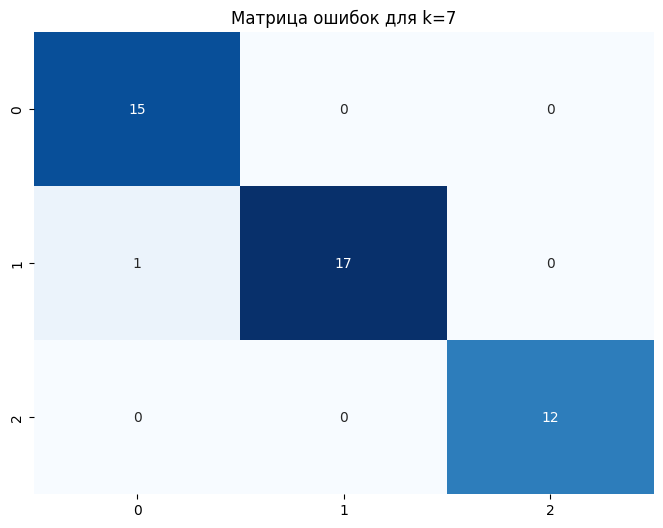

In [62]:

best_knn = KNeighborsClassifier(n_neighbors=7, metric='minkowski', p=2)
best_knn.fit(X_train_scaled, y_train)

# 2. Generate predictions on the test set
y_pred = best_knn.predict(X_test_scaled)

# 3. Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

plt.title('Матрица ошибок для k=7')
plt.show()

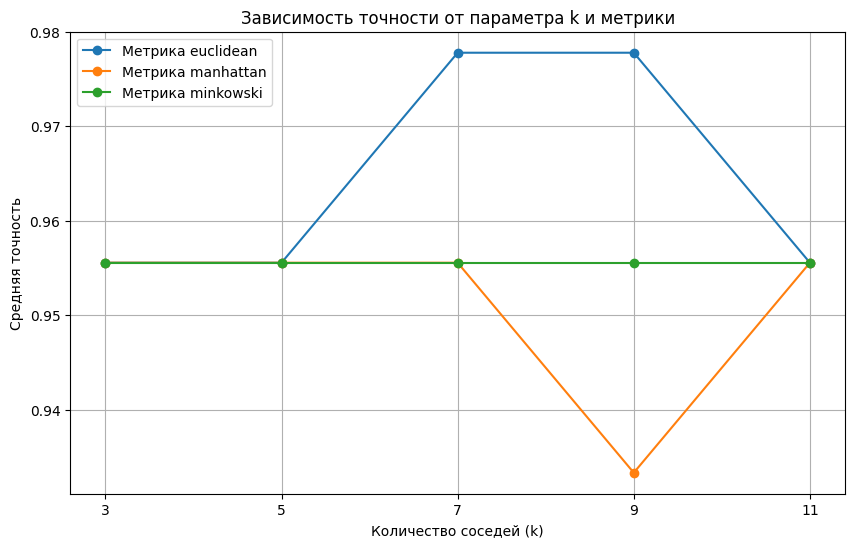

In [112]:
plt.figure(figsize=(10, 6))
for metric in metrics:
    plt.plot(k_values, results_df[(results_df['metric'] == metric) &(results_df['weights'] == 'uniform')]['accuracy when scaled'], marker='o', label=f'Метрика {metric}')

plt.title('Зависимость точности от параметра k и метрики')
plt.xlabel('Количество соседей (k)')
plt.ylabel('Средняя точность')
plt.xticks(k_values)
plt.grid(True)
plt.legend()
plt.show()

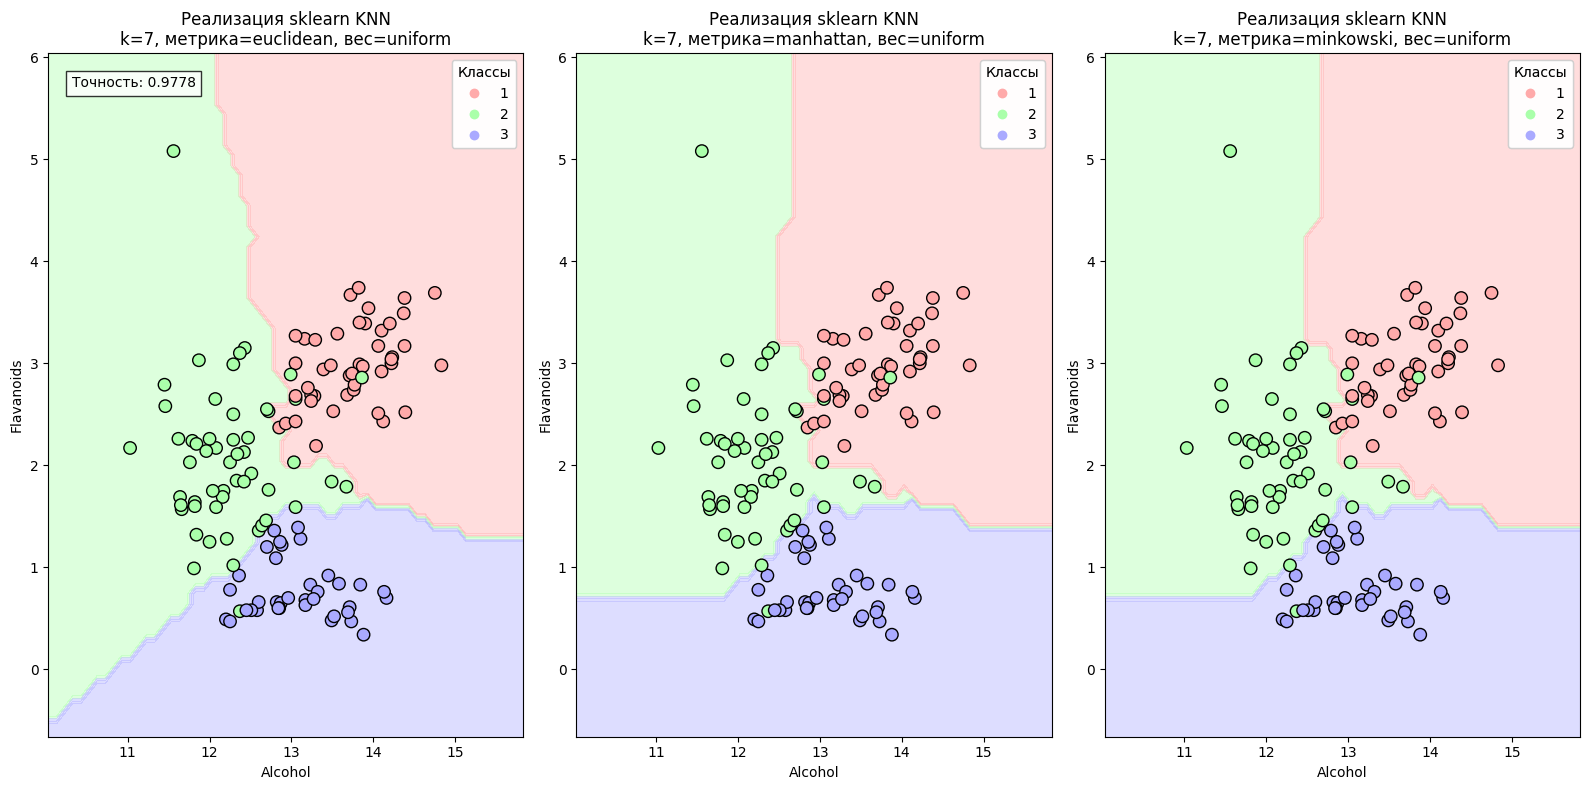

In [ ]:
# Функция для отображения границ решения
def plot_decision_boundaries(X, y, model, ax=None, title="Decision Boundaries"):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Определяем границы графика с небольшим запасом
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Создаем сетку точек для построения границы
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    # Предсказываем класс для каждой точки сетки
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Определяем цветовую схему
    colors = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])

    # Отображаем границы решения
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=colors)

    # Отображаем обучающие точки
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, s=80, edgecolor='k', cmap=colors)

    # Добавляем легенду
    legend1 = ax.legend(*scatter.legend_elements(), title="Классы")
    ax.add_artist(legend1)

    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_title(title)
    ax.set_xlabel('Признак 1')
    ax.set_ylabel('Признак 2')

    return ax

best_params = results_df.loc[results_df['accuracy when scaled'].idxmax()]
k_best = int(best_params['k'])
metric_best = best_params['metric']
weights_best = best_params['weights']

fig, axes = plt.subplots(1, 3, figsize=(16, 8))

sklearn_metric = 'minkowski' if metric_best == 'euclidean' else metric_best
sklearn_p = 2 if metric_best == 'euclidean' else (3 if metric_best == 'minkowski' else 1)
X_train_2d = X_train[:, [0, 6]] if isinstance(X_train, np.ndarray) else X_train.iloc[:, [0, 6]].values
y_train_flat = np.ravel(y_train)
#1) Лучшая модель - с евклидовой метрикой
euclidean_knn = KNeighborsClassifier(n_neighbors=k_best, metric=sklearn_metric, weights=weights_best, p=sklearn_p)
euclidean_knn.fit(X_train_2d, y_train_flat)
plot_decision_boundaries(X_train_2d, y_train_flat, euclidean_knn, ax=axes[0],
                        title=f'Реализация sklearn KNN\nk={k_best}, метрика={metric_best}, вес={weights_best}')
#2)Модель с метрикой manhattan
manhattan_knn = KNeighborsClassifier(n_neighbors=k_best, metric="manhattan", weights=weights_best, p=sklearn_p)
manhattan_knn.fit(X_train_2d, y_train_flat)

plot_decision_boundaries(X_train_2d, y_train_flat, manhattan_knn, ax=axes[1], 
                         title=f'Реализация sklearn KNN\nk={k_best}, метрика=manhattan, вес={weights_best}')
#3)Модель с метрикой minkowski
minkowski_knn = KNeighborsClassifier(n_neighbors=k_best, metric="manhattan", weights=weights_best, p=sklearn_p)
minkowski_knn.fit(X_train_2d, y_train_flat)

plot_decision_boundaries(X_train_2d, y_train_flat, minkowski_knn, ax=axes[2], 
                         title=f'Реализация sklearn KNN\nk={k_best}, метрика=minkowski, вес={weights_best}')

axes[0].text(0.05, 0.95, f'Точность: {best_params["accuracy when scaled"]:.4f}', transform=axes[0].transAxes,
           bbox=dict(facecolor='white', alpha=0.8))
axes[0].set_xlabel('Alcohol')
axes[0].set_ylabel('Flavanoids')
axes[1].set_xlabel('Alcohol')
axes[1].set_ylabel('Flavanoids')
axes[2].set_xlabel('Alcohol')
axes[2].set_ylabel('Flavanoids')
plt.tight_layout()
plt.show()

При создании последних плотов урезал датасет до двух признаков - Flavanoids и Alchahol - одних из самых сильно коррелирующих с таргетом. За основу - вдохновение - брал написанный для лекции по KNN класс plot_desicion_boundaries, адаптировал остальное под свой датасет и задачи

Выводы:
- масштабирование сильно влияет на качество - точность при масшатбировании в среднем на 15-20 процентов больше точности модели без масштабирования
- Модель лучше всего показывает себя на евклидовой метрике
- Точность лучших моделей очень высокая - подозреваю, что это из-за малого количества данных
- Лучее количесство соседей - 7 либо 9. При больших или меньших значениях качество модели начинает падать

**5. Подбор гиперпараметров**



c:\Coding Projects\ml-course-homeworks\.venv\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Coding Projects\ml-course-homeworks\.venv\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Coding Projects\ml-course-homeworks\.venv\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Coding Projects\ml-course-homeworks\.venv\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y

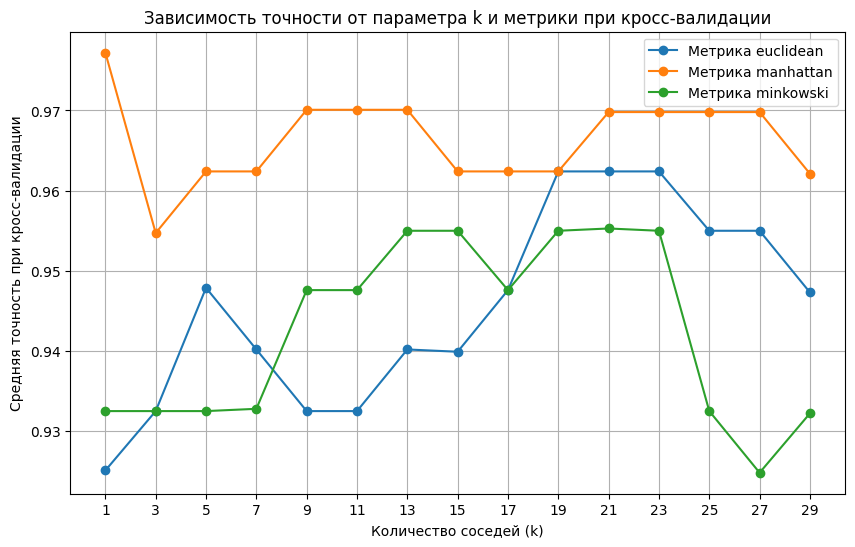

In [120]:
k_range = range(1, 31, 2)
metrics = ['euclidean', 'manhattan', 'minkowski']
cv_scores = {}


for metric in metrics:
    cv_scores[metric] = []
    sklearn_p = 2 if metric == 'euclidean' else (3 if metric == 'minkowski' else 1)
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric, p=sklearn_p)
        scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
        cv_scores[metric].append(scores.mean())

# Визуализация результатов
plt.figure(figsize=(10, 6))
for metric in metrics:
    plt.plot(k_range, cv_scores[metric], marker='o', label=f'Метрика {metric}')

plt.title('Зависимость точности от параметра k и метрики при кросс-валидации')
plt.xlabel('Количество соседей (k)')
plt.ylabel('Средняя точность при кросс-валидации')
plt.xticks(k_range)
plt.grid(True)
plt.legend()
plt.show()

In [119]:
#Оптимальные значения k для каждой метрики
for metric in metrics:
    best_k = k_range[np.argmax(cv_scores[metric])]
    best_score = max(cv_scores[metric])
    print(f"Метрика {metric}: Лучшее значение k = {best_k}, точность = {best_score:.4f}")

Метрика euclidean: Лучшее значение k = 19, точность = 0.9624
Метрика manhattan: Лучшее значение k = 1, точность = 0.9772
Метрика minkowski: Лучшее значение k = 21, точность = 0.9553


- К удивлению, По результатам кросс-валидации сложилась обратная ситуация: у метрики manhattan самые лучшие результаты точности (до кросс-валидации было наоборот), причем лучшее значение гиперпараметра K=1. У других же метрик максимальное значение точности наблюдается при k=19 и k=21. Что интересно, точность начинает падать ниже 90% только после K=67.
- Такая разница при обучении без кросс-валидации и с ее помощью является, скорее всего, следствием низковероятной удачи распределения примеров при разделении датасета на треин и тест
- 